**Setup & Importing Libraries**

In [3]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

**Loading the Data**

In [4]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/std_dropout_prediction_project/Predict_Students_Dropout_and_Academic_Success.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


**Initial Data Audit (Shape & Info)**

In [5]:
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Data Types & Missing Values Overview ---")
df.info()

--- Dataset Shape ---
Rows: 4424, Columns: 37

--- First 5 Rows ---


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



--- Data Types & Missing Values Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  


**Decoding Categorical Variables**

In [6]:
df.columns = df.columns.str.strip()

# Apply mappings to the dataframe
marital_map = {1: 'Single', 2: 'Married', 3: 'Widower', 4: 'Divorced', 5: 'Facto Union', 6: 'Legally Separated'}
df['Marital status'] = df['Marital status'].map(marital_map)

gender_map = {1: 'Male', 0: 'Female'}
df['Gender'] = df['Gender'].map(gender_map)

attendance_map = {1: 'Daytime', 0: 'Evening'}
df['Daytime/evening attendance'] = df['Daytime/evening attendance'].map(attendance_map)

yes_no_map = {1: 'Yes', 0: 'No'}
binary_cols = ['Displaced', 'Educational special needs', 'Debtor',
               'Tuition fees up to date', 'Scholarship holder', 'International']
for col in binary_cols:
    df[col] = df[col].map(yes_no_map)

course_map = {
    33: 'Biofuel Production', 171: 'Animation & Multimedia', 8014: 'Social Service (Eve)',
    9003: 'Agronomy', 9070: 'Communication Design', 9085: 'Veterinary Nursing',
    9119: 'Informatics Eng.', 9130: 'Equiniculture', 9147: 'Management',
    9238: 'Social Service', 9254: 'Tourism', 9500: 'Nursing', 9556: 'Oral Hygiene',
    9670: 'Advertising & Marketing', 9773: 'Journalism', 9853: 'Basic Education',
    9991: 'Management (Eve)'
}
df['Course'] = df['Course'].map(course_map)

nationality_map = {
    1: 'Portuguese', 2: 'German', 6: 'Spanish', 11: 'Italian', 13: 'Dutch',
    14: 'English', 17: 'Lithuanian', 21: 'Angolan', 22: 'Cape Verdean',
    24: 'Guinean', 25: 'Mozambican', 26: 'Santomean', 32: 'Turkish',
    41: 'Brazilian', 62: 'Romanian', 100: 'Moldova', 101: 'Mexican',
    103: 'Ukrainian', 105: 'Russian', 108: 'Cuban', 109: 'Colombian'
}
# Rename 'Nacionality' column to 'Nationality'
df.rename(columns={'Nacionality': 'Nationality'}, inplace=True)
df['Nationality'] = df['Nationality'].map(nationality_map)

application_mode_map = {
    1: '1st phase - general contingent', 2: 'Ordinance No. 612/93',
    5: '1st phase - special contingent (Azores Island)', 7: 'Holders of other higher courses',
    10: 'Ordinance No. 854-B/99', 15: 'International student (bachelor)',
    16: '1st phase - special contingent (Madeira Island)', 17: '2nd phase - general contingent',
    18: '3rd phase - general contingent', 26: 'Ordinance No. 533-A/99, item b2) (Different Plan)',
    27: 'Ordinance No. 533-A/99, item b3 (Other Institution)', 39: 'Over 23 years old',
    42: 'Transfer', 43: 'Change of course', 44: 'Technological specialization diploma holders',
    51: 'Change of institution/course', 53: 'Short cycle diploma holders',
    57: 'Change of institution/course (International)'
}
df['Application mode'] = df['Application mode'].map(application_mode_map).fillna('Unknown')

prev_qualification_map = {
    1: 'Secondary education', 2: "Higher education - bachelor's degree",
    3: 'Higher education - degree', 4: "Higher education - master's",
    5: 'Higher education - doctorate', 6: 'Frequency of higher education',
    9: '12th year of schooling - not completed', 10: '11th year of schooling - not completed',
    12: 'Other - 11th year of schooling', 14: '10th year of schooling',
    15: '10th year of schooling - not completed', 19: 'Basic education 3rd cycle (9th/10th/11th year)',
    38: 'Basic education 2nd cycle (6th/7th/8th year)', 39: 'Technological specialization course',
    40: 'Higher education - degree (1st cycle)', 42: 'Professional higher technical course',
    43: 'Higher education - master (2nd cycle)'
}
df['Previous qualification'] = df['Previous qualification'].map(prev_qualification_map).fillna('Unknown')

parent_qualification_map = {
    1: 'Secondary Education - 12th Year', 2: "Higher Education - Bachelor's Degree",
    3: 'Higher Education - Degree', 4: "Higher Education - Master's",
    5: 'Higher Education - Doctorate', 6: 'Frequency of Higher Education',
    9: '12th Year - Not Completed', 10: '11th Year - Not Completed',
    11: '7th Year (Old)', 12: 'Other - 11th Year', 13: '2nd year complementary high school',
    14: '10th Year', 18: 'General commerce course', 19: 'Basic Education 3rd Cycle',
    20: 'Complementary High School Course', 22: 'Technical-professional course',
    25: 'Complementary High School - not concluded', 26: '7th year of schooling',
    27: '2nd cycle of general high school', 29: '9th Year - Not Completed',
    30: '8th year of schooling', 31: 'General Course of Administration and Commerce',
    33: 'Supplementary Accounting and Administration', 34: 'Unknown',
    35: "Can't read or write", 36: 'Can read without 4th year',
    37: 'Basic education 1st cycle (4th/5th year)', 38: 'Basic Education 2nd Cycle',
    39: 'Technological specialization course', 40: 'Higher education - degree (1st cycle)',
    41: 'Specialized higher studies course', 42: 'Professional higher technical course',
    43: 'Higher Education - Master (2nd cycle)', 44: 'Higher Education - Doctorate (3rd cycle)'
}
df["Mother's qualification"] = df["Mother's qualification"].map(parent_qualification_map).fillna('Unknown')
df["Father's qualification"] = df["Father's qualification"].map(parent_qualification_map).fillna('Unknown')

mother_occupation_map = {
    0: 'Student', 1: 'Legislative/Executive Directors & Managers', 2: 'Intellectual/Scientific Specialists',
    3: 'Intermediate Level Technicians', 4: 'Administrative staff',
    5: 'Personal Services, Security and Sellers', 6: 'Farmers and Skilled Agriculture/Forestry',
    7: 'Skilled Industry/Construction Workers', 8: 'Machine Operators and Assembly Workers',
    9: 'Unskilled Workers', 10: 'Armed Forces Professions', 90: 'Other Situation', 99: '(blank)',
    122: 'Health professionals', 123: 'Teachers', 125: 'ICT Specialists',
    131: 'Intermediate science/engineering technicians', 132: 'Intermediate health technicians',
    134: 'Intermediate legal/social/sports technicians', 141: 'Office workers and secretaries',
    143: 'Data/accounting/financial operators', 144: 'Other administrative support staff',
    151: 'Personal service workers', 152: 'Sellers', 153: 'Personal care workers',
    171: 'Skilled construction workers', 173: 'Skilled printing/jewelers/artisans',
    175: 'Food processing/woodworking/clothing workers', 191: 'Cleaning workers',
    192: 'Unskilled agriculture/forestry workers', 193: 'Unskilled extractive/construction/transport',
    194: 'Meal preparation assistants'
}

# Father's occupations (Copy Mother's, then add the extra codes specific to Fathers)
father_occupation_map = mother_occupation_map.copy()
father_occupation_map.update({
    101: 'Armed Forces Officers', 102: 'Armed Forces Sergeants', 103: 'Other Armed Forces personnel',
    112: 'Directors of administrative/commercial services', 114: 'Hotel/catering/trade directors',
    121: 'Physical sciences/math/engineering specialists', 124: 'Finance/accounting/PR specialists',
    135: 'ICT technicians', 154: 'Protection and security services personnel',
    161: 'Market-oriented farmers/agricultural workers', 163: 'Subsistence farmers/fishermen/hunters',
    172: 'Skilled metallurgy/metalworking workers', 174: 'Skilled electricity/electronics workers',
    181: 'Fixed plant and machine operators', 182: 'Assembly workers',
    183: 'Vehicle drivers and mobile equipment operators', 195: 'Street vendors and service providers'
})

df["Mother's occupation"] = df["Mother's occupation"].map(mother_occupation_map).fillna('Unknown')
df["Father's occupation"] = df["Father's occupation"].map(father_occupation_map).fillna('Unknown')

print("✅ ALL remaining columns successfully decoded based on the official UCI Data Dictionary!")

print("✅ Data successfully decoded! Check your dataframe by running `df.head()`")

✅ ALL remaining columns successfully decoded based on the official UCI Data Dictionary!
✅ Data successfully decoded! Check your dataframe by running `df.head()`


In [7]:
print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Data Types & Missing Values Overview ---")
df.info()


--- First 5 Rows ---


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,Single,2nd phase - general contingent,5,Animation & Multimedia,Daytime,Secondary education,122.0,Portuguese,Basic Education 3rd Cycle,Other - 11th Year,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,International student (bachelor),1,Tourism,Daytime,Secondary education,160.0,Portuguese,Secondary Education - 12th Year,Higher Education - Degree,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1st phase - general contingent,5,Communication Design,Daytime,Secondary education,122.0,Portuguese,Basic education 1st cycle (4th/5th year),Basic education 1st cycle (4th/5th year),...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,2nd phase - general contingent,2,Journalism,Daytime,Secondary education,122.0,Portuguese,Basic Education 2nd Cycle,Basic education 1st cycle (4th/5th year),...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,Over 23 years old,1,Social Service (Eve),Evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year),Basic Education 2nd Cycle,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



--- Data Types & Missing Values Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   object 
 1   Application mode                                4424 non-null   object 
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   object 
 4   Daytime/evening attendance                      4424 non-null   object 
 5   Previous qualification                          4424 non-null   object 
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nationality                                     4424 non-null   object 
 8   Mother's qualification                          4424 non-null   object 


**Deep Data Audit (Missing Values & Duplicates)**

In [8]:
print("--- Missing Values per Column ---")
missing = df.isnull().sum()
display(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

print("\n--- Duplicated Rows ---")
duplicates = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicates}")

# If there are duplicates, removing them
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed successfully!")

--- Missing Values per Column ---


'No missing values found!'


--- Duplicated Rows ---
Number of duplicated rows: 0


**Statistical Summary**

In [9]:
print("--- Numerical Features Summary ---")
display(df.describe())

print("\n--- Categorical Features Summary ---")
display(df.describe(include=['object', 'category']))

--- Numerical Features Summary ---


,Application order,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.727848,132.613314,126.978119,23.265145,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,1.313793,13.188332,14.482001,7.587816,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,0.000000,95.000000,95.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,125.000000,117.900000,19.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,133.100000,126.100000,20.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,2.000000,140.000000,134.800000,25.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,9.000000,190.000000,190.000000,70.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000



--- Categorical Features Summary ---


,Marital status,Application mode,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,International,Target
count,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424
unique,6,18,17,2,17,21,29,34,32,46,2,2,2,2,2,2,2,3
top,Single,1st phase - general contingent,Nursing,Daytime,Secondary education,Portuguese,Secondary Education - 12th Year,Basic education 1st cycle (4th/5th year),Unskilled Workers,Unskilled Workers,Yes,No,No,Yes,Female,No,No,Graduate
freq,3919,1708,766,3941,3717,4314,1069,1209,1577,1010,2426,4373,3921,3896,2868,3325,4314,2209


**Target Variable Analysis**

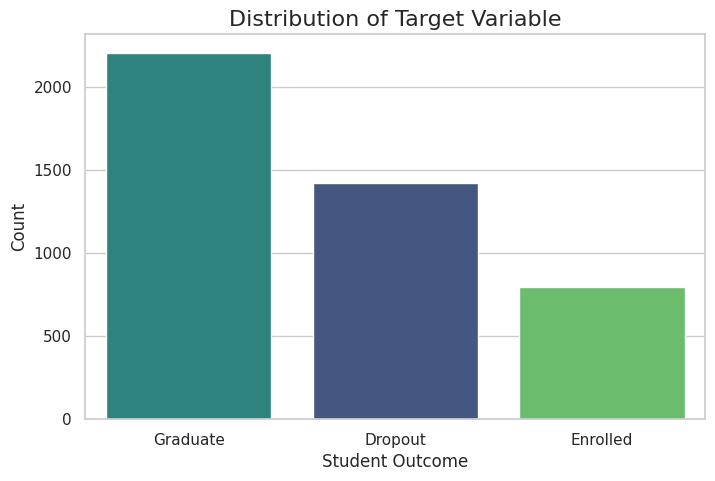

Target Variable Percentages:


,proportion
Target,
Graduate,49.932188
Dropout,32.120253
Enrolled,17.947559


In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Target', hue='Target', palette='viridis', legend=False, order=df['Target'].value_counts().index)
plt.title('Distribution of Target Variable', fontsize=16)
plt.xlabel('Student Outcome', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# Calculating percentages
target_counts = df['Target'].value_counts(normalize=True) * 100
print("Target Variable Percentages:")
display(target_counts)

**Separating Features by Type**

In [11]:
X_num = df.select_dtypes(include=[np.number]).columns.drop('Target', errors='ignore')
X_cat = df.select_dtypes(exclude=[np.number]).columns.drop('Target', errors='ignore')

print(f"Number of Numerical Features: {len(X_num)}")
print(f"Number of Categorical Features: {len(X_cat)}")

Number of Numerical Features: 19
Number of Categorical Features: 17


**Univariate Analysis (Numerical Features)**

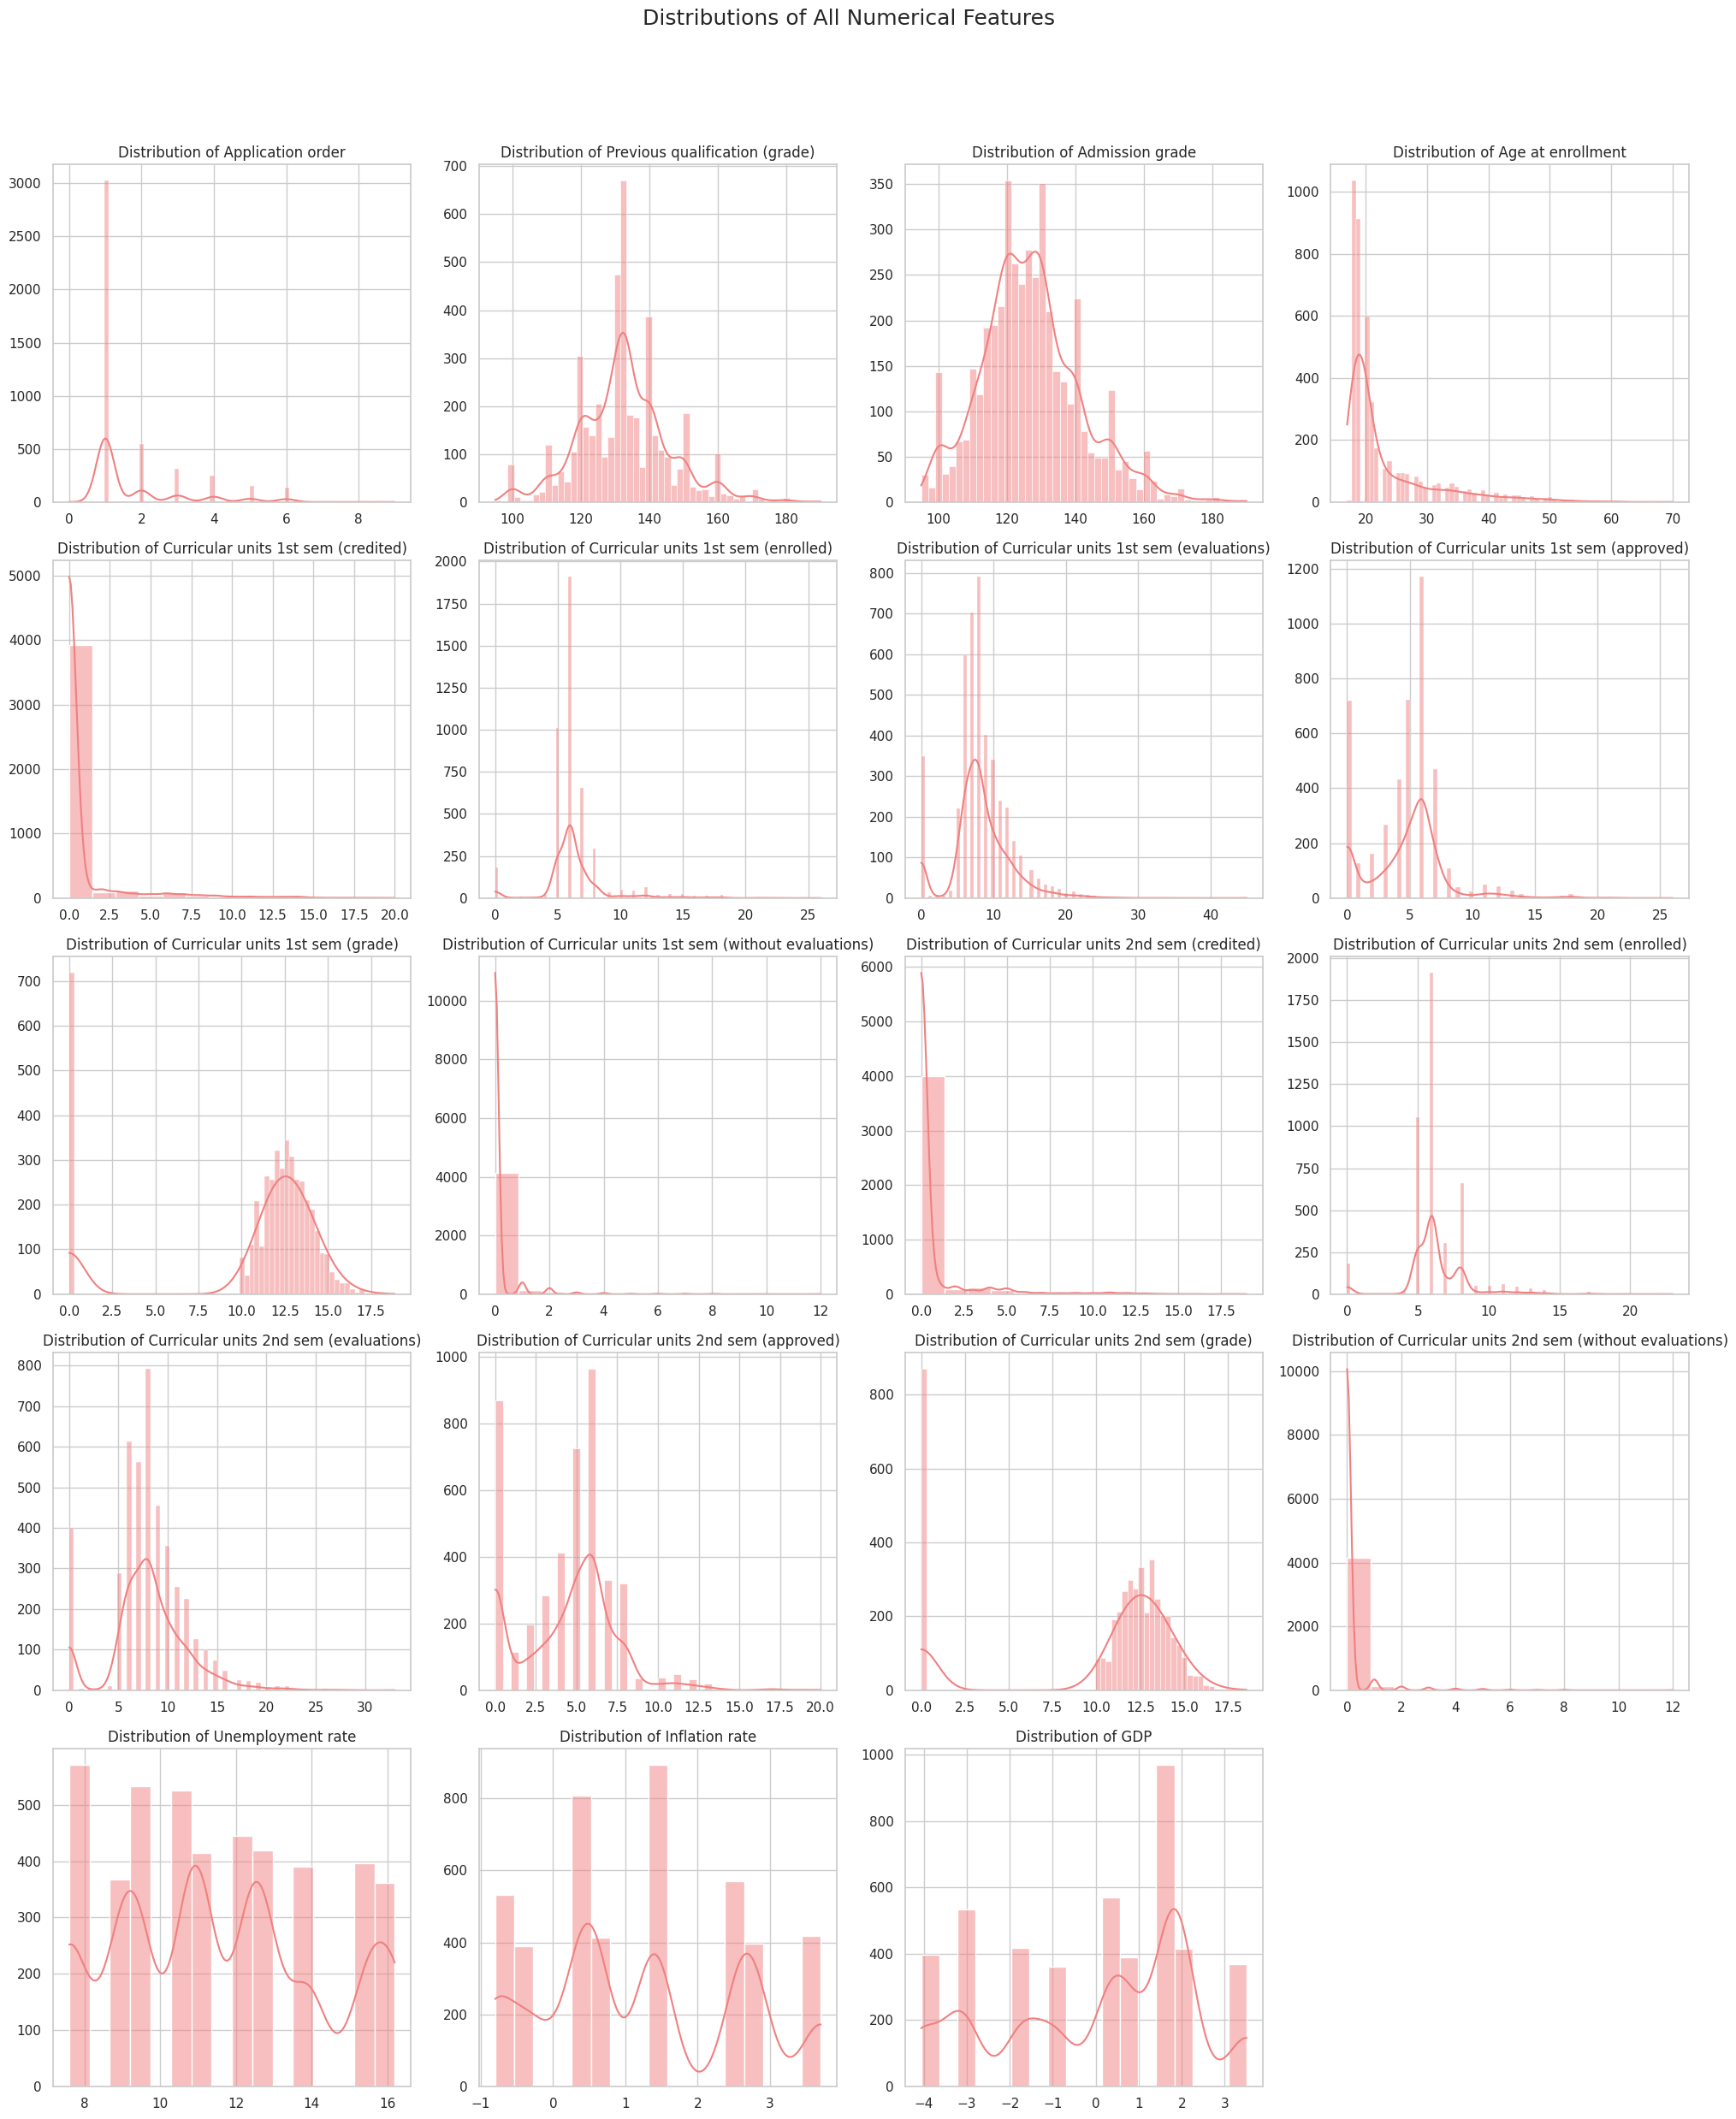

In [12]:
# Ploting all numerical features in a larger grid
# Create a 4x5 grid for 19 features (one will be empty)
fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(X_num):
    if i < len(axes): # Ensure we don't go out of bounds if X_num is smaller than axes
        sns.histplot(df[col], kde=True, ax=axes[i], color='lightcoral')
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('') # Clear x-label to prevent overlap
        axes[i].set_ylabel('') # Clear y-label to prevent overlap

# Remove any unused subplots
for j in range(len(X_num), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distributions of All Numerical Features', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

**Univariate Analysis (Categorical Features)**

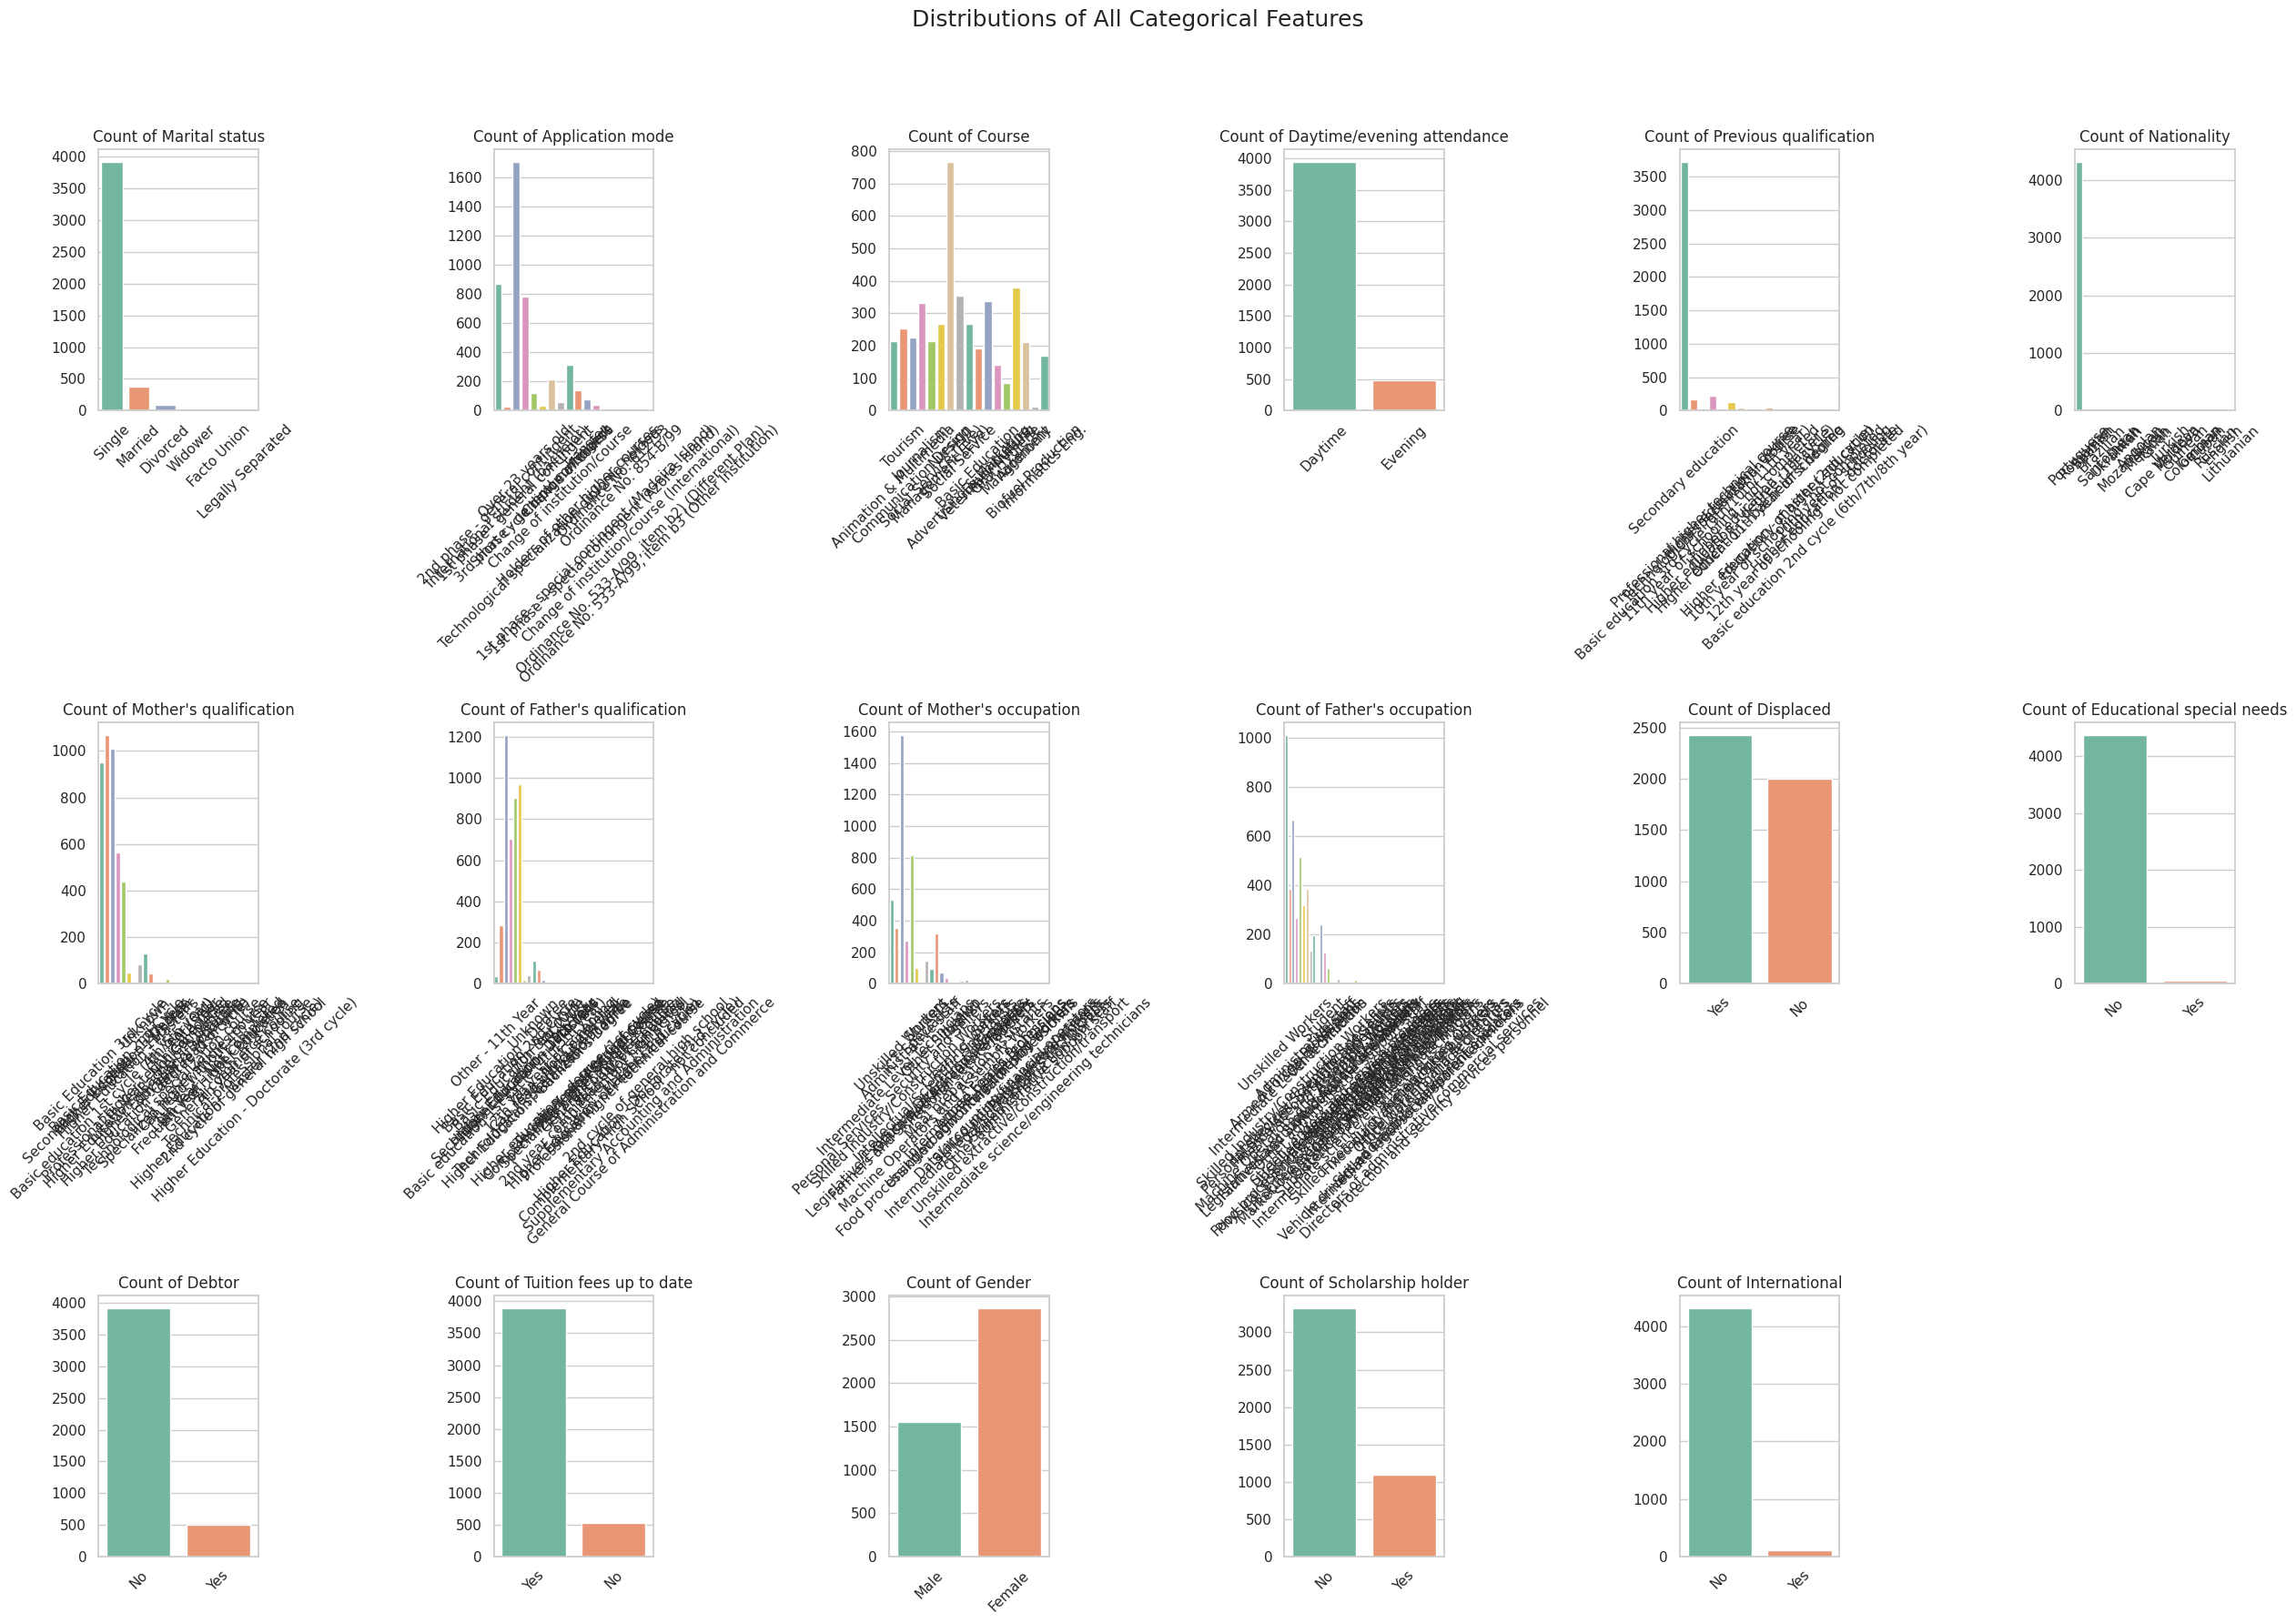

In [13]:
# Plotting all categorical features in a larger grid
# Create a 3x6 grid for 17 features (one will be empty)
fig, axes = plt.subplots(3, 6, figsize=(25, 18)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(X_cat):
    if i < len(axes): # Ensure we don't go out of bounds if X_cat is smaller than axes
        sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', hue=col, legend=False)
        axes[i].set_title(f'Count of {col}', fontsize=12)
        axes[i].set_xlabel('') # Clear x-label to prevent overlap
        axes[i].set_ylabel('') # Clear y-label to prevent overlap
        axes[i].tick_params(axis='x', rotation=45) # Rotate labels so they don't overlap

# Remove any unused subplots
for j in range(len(X_cat), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distributions of All Categorical Features', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

**Bivariate Analysis (Correlation Heatmap)**

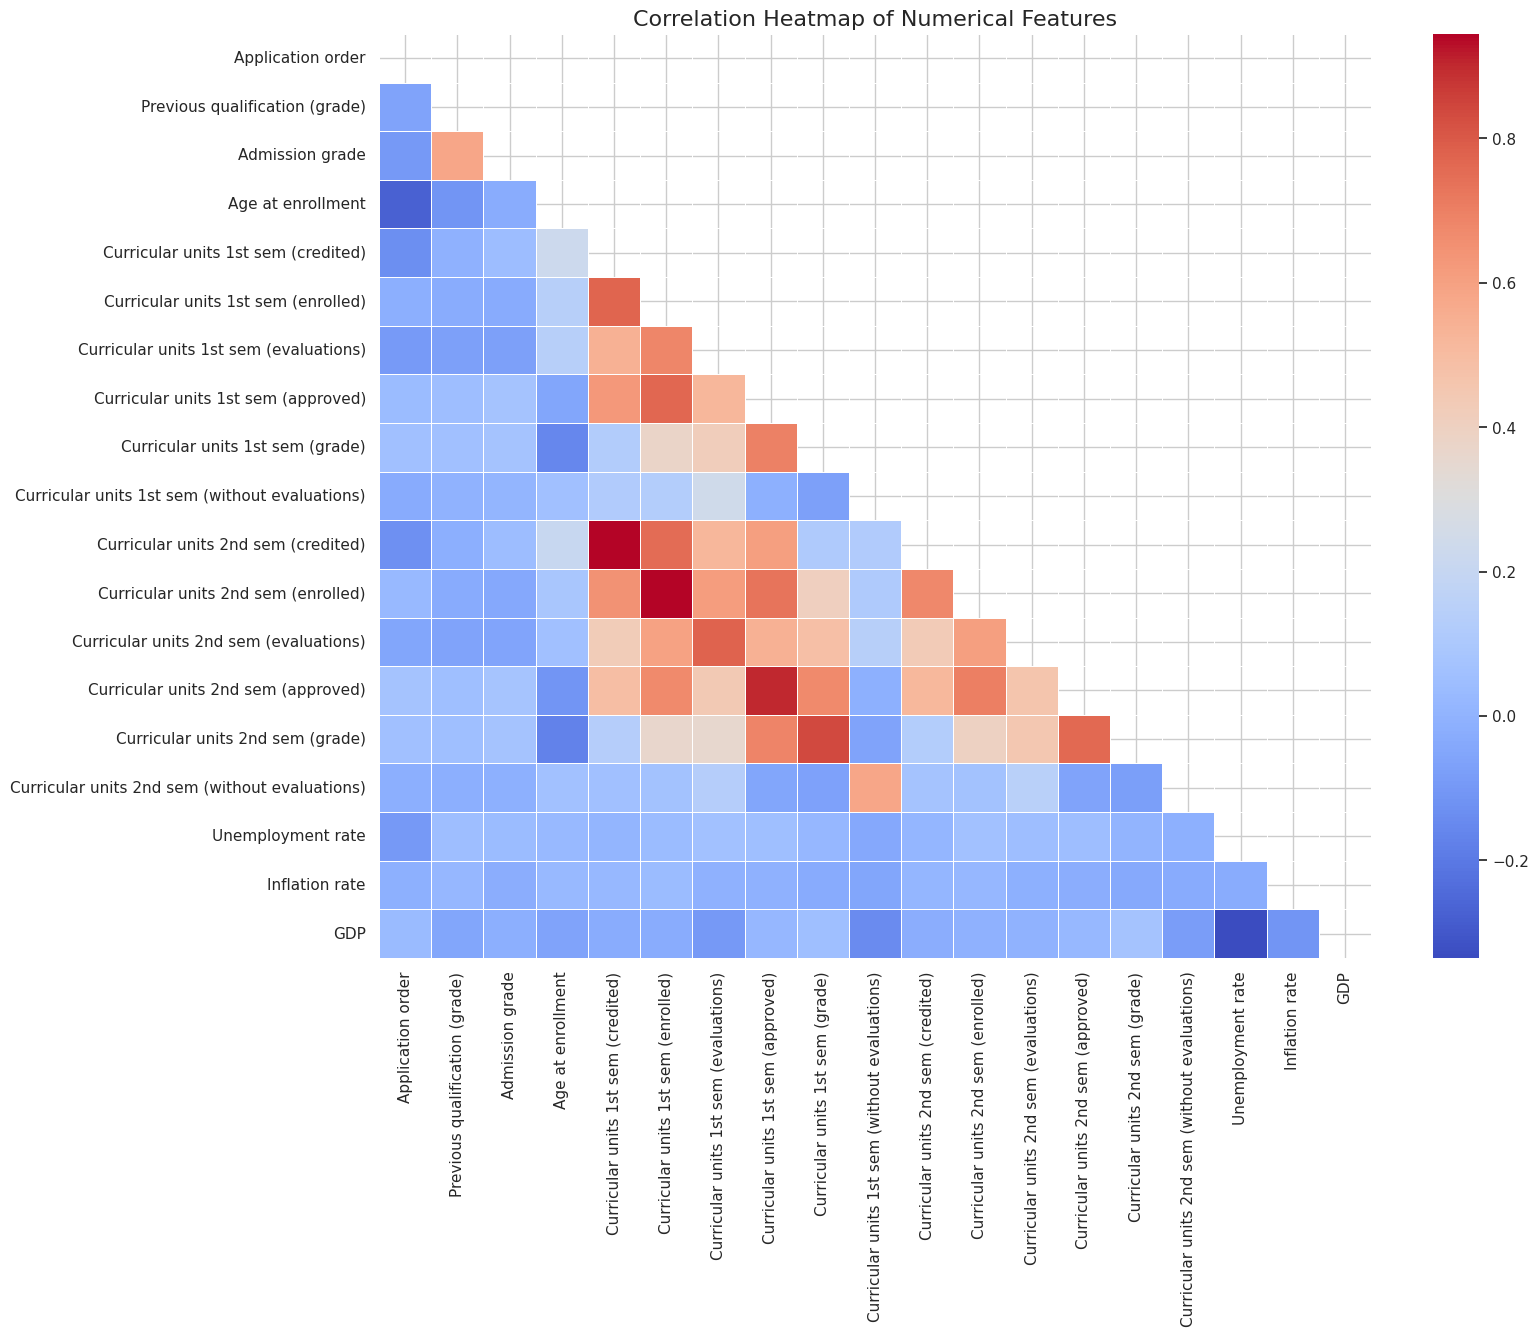

In [14]:
plt.figure(figsize=(16, 12))
correlation_matrix = df[X_num].corr()

# Creating a mask to hide the upper triangle (since it's redundant)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

**Feature vs Target Correlation**

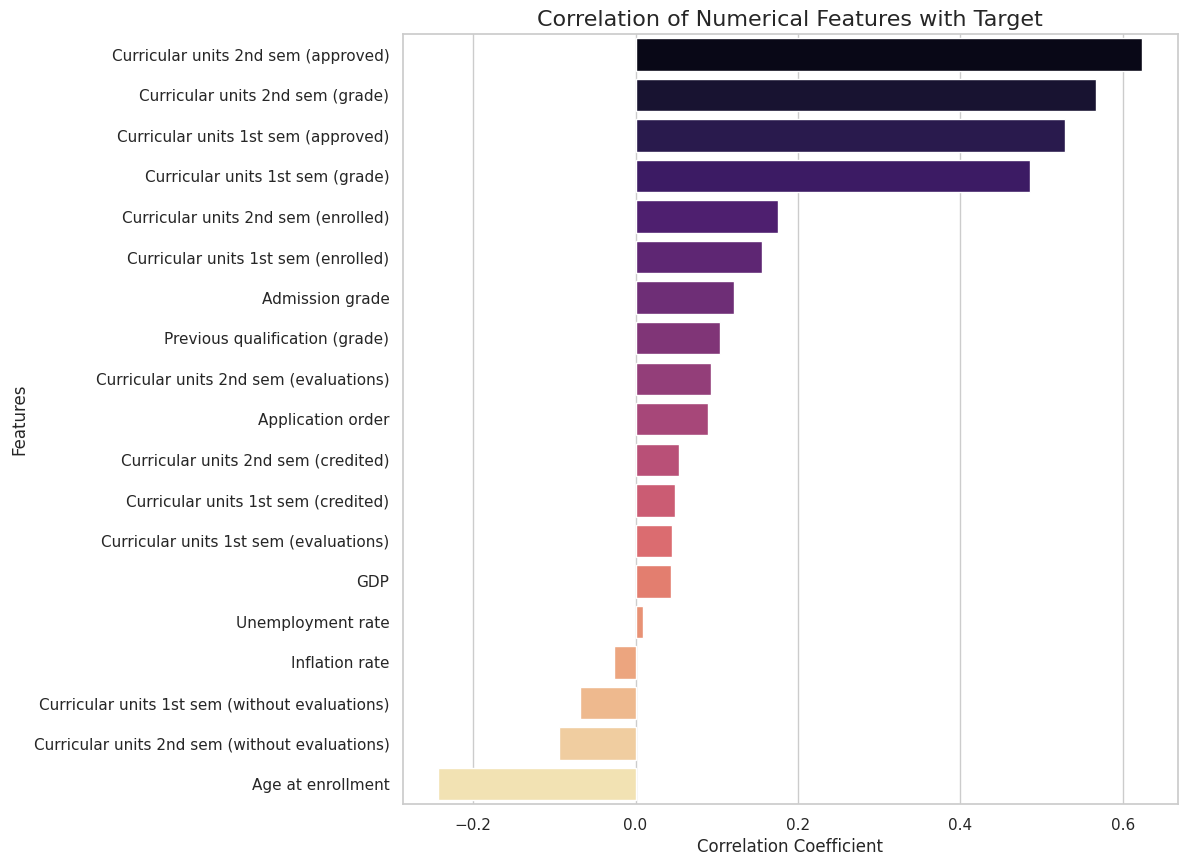

In [17]:
# Temporarily encoding Target to numbers for correlation math
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target_Encoded'] = df['Target'].map(target_map)

# Calculating correlation of all numerical features with the Target
target_corr = df[X_num].corrwith(df['Target_Encoded']).sort_values(ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='magma', hue=target_corr.index, legend=False)
plt.title('Correlation of Numerical Features with Target', fontsize=16)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

**Outlier Detection(Numerical Features)**

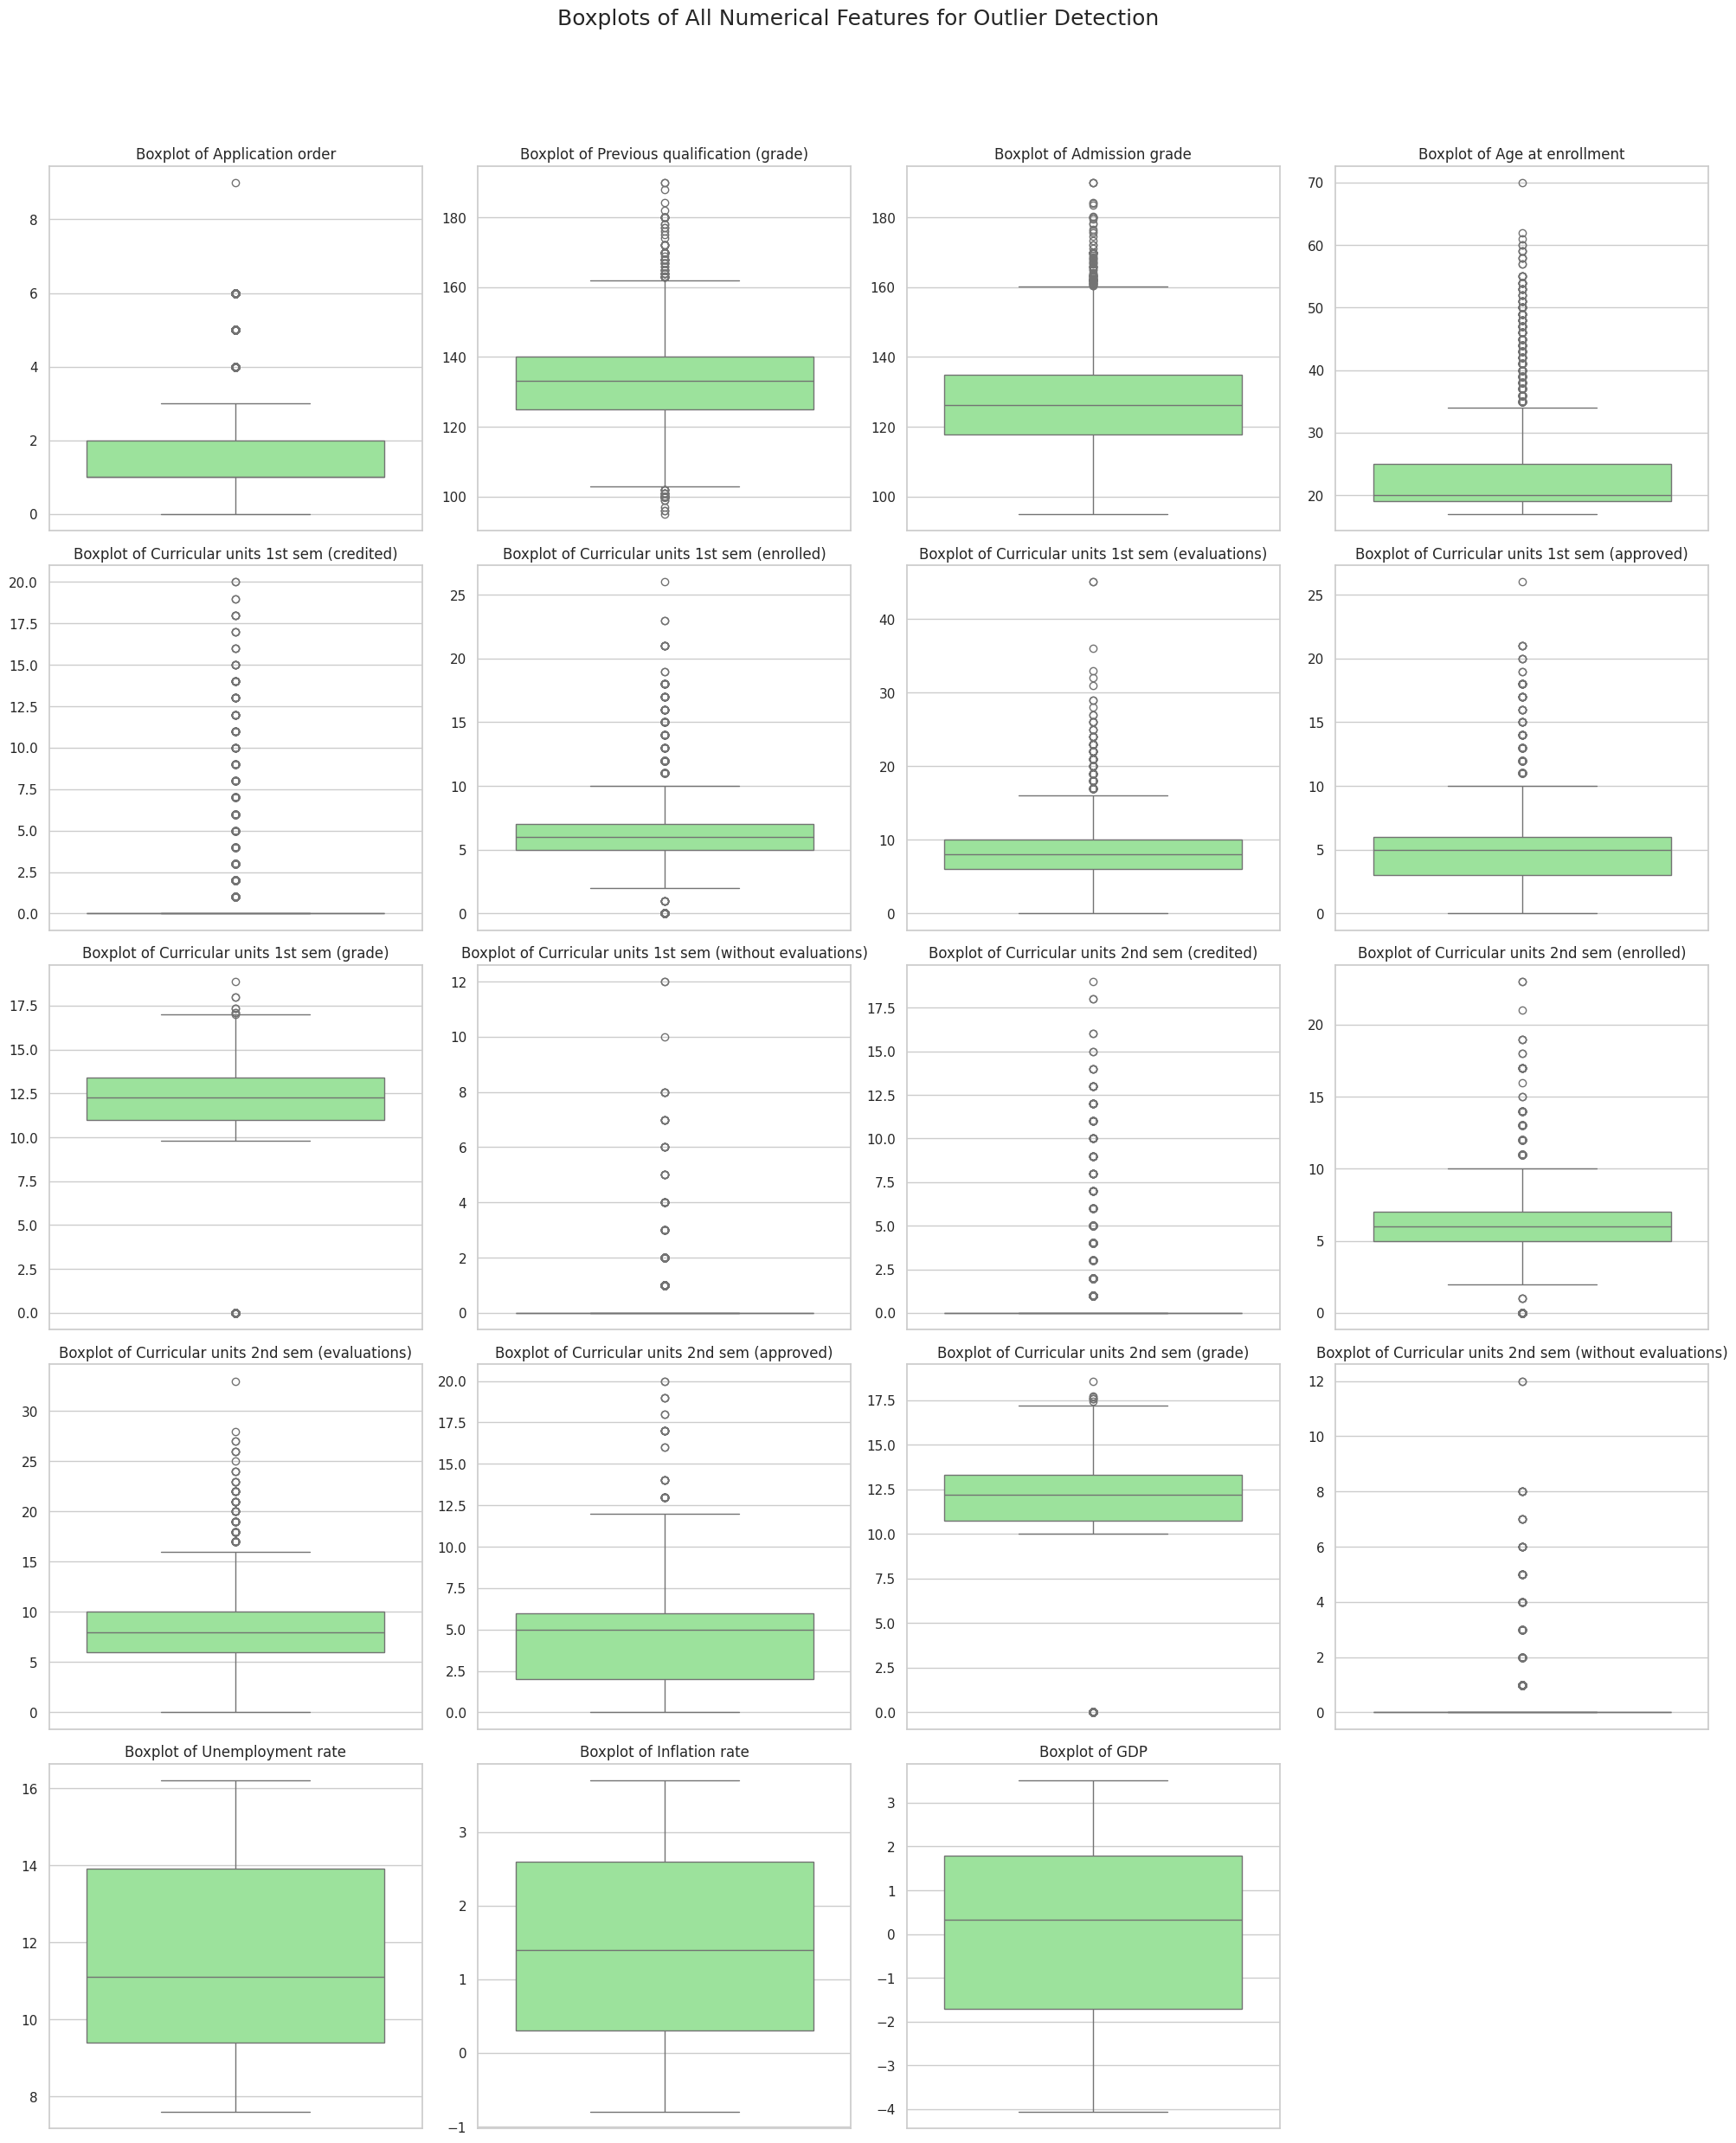

In [16]:
num_features = len(X_num)
rows = (num_features + 3) // 4  # Calculate rows needed for a 4-column layout

fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(X_num):
    if i < len(axes): # Ensure we don't go out of bounds
        sns.boxplot(data=df, y=col, ax=axes[i], color='lightgreen')
        axes[i].set_title(f'Boxplot of {col}', fontsize=12)
        axes[i].set_ylabel('') # Clear y-label to prevent overlap

# Remove any unused subplots
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots of All Numerical Features for Outlier Detection', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()